# 03.3 · Resolution, alpha and tensor layout

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain resolution, alpha and tensor layout using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[01 · Python for Computer Vision](../../01-python-for-computer-vision/README.md), [02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Imagine an image as a spreadsheet. A grayscale cell holds one intensity; an RGB pixel holds three channel values. Sampling chooses where measurements are taken, and quantization chooses which intensity values can be represented. The array is the measurement, not the scene itself.

## 2. Intuition

Resolution describes the sampling grid. Reducing it loses spatial information; enlarging it cannot recover missing detail. Alpha compositing combines foreground and background using opacity. HWC and CHW contain the same values in different axis orders; reshape alone does not perform this permutation. Metadata such as EXIF orientation can change intended display.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 3
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
C=\alpha F+(1-\alpha)B
$$

C is the composited channel, F foreground intensity, B background intensity, and α opacity between zero and one. Half-opacity red over white gives RGB [1, 0.5, 0.5] in normalized units.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
foreground = np.array([1.0, 0.0, 0.0])
background = np.ones(3)
alpha = 0.5
composite = alpha * foreground + (1 - alpha) * background
assert np.allclose(composite, [1.0, 0.5, 0.5])
print(composite)

[1.  0.5 0.5]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The experiments separate channels, quantize levels with rounding, resample the spatial grid and transpose axes. Image dimensions and memory size are measured from the actual array.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def fundamentals(lesson, seed, amount):
    image = picture(seed)
    if lesson == 0:
        panels = {'RGB': image, 'Red channel': image[...,0], 'Grayscale': n.gray(image)}
        metrics = {'shape': list(image.shape), 'dtype': str(image.dtype), 'array_bytes': image.nbytes}
    elif lesson == 1:
        levels = max(2, int(8/amount))
        quantized = np.rint(image/255*(levels-1))/(levels-1)
        panels = {'Original': image, f'Quantized to {levels} levels': quantized, 'Quantization absolute error': np.abs(image/255-quantized).mean(2)}
        metrics = {'mse': float(np.mean((image/255-quantized)**2)), 'levels': levels}
    else:
        reduced = cv2.resize(image, (16,16), interpolation=cv2.INTER_AREA)
        restored = cv2.resize(reduced, (96,96), interpolation=cv2.INTER_NEAREST)
        alpha = np.linspace(0,1,96)[None,:,None]
        composite = (image*alpha+255*(1-alpha)).astype(np.uint8)
        panels = {'Low-resolution resampling': restored, 'Alpha on white': composite, 'HWC to CHW back': image.transpose(2,0,1).transpose(1,2,0)}
        metrics = {'tensor_chw_shape': list(image.transpose(2,0,1).shape)}
    return Result('03 · Pixels, sampling and representation', panels, metrics=metrics)

{
  "tensor_chw_shape": [
    3,
    96,
    96
  ]
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import gray

display(Code(inspect.getsource(gray), language="python"))

def gray(image):
    """Convert RGB to float grayscale; leave 2D input as floating point."""
    values = np.asarray(image, dtype=float)
    return values @ np.array([.299, .587, .114]) if values.ndim == 3 else values

## 8. Experiment

Reduce the number of intensity levels while leaving resolution fixed. Then reduce resolution with all 256 levels. Describe how the two artifacts differ.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "tensor_chw_shape": [
      3,
      96,
      96
    ]
  },
  "second_seed": {
    "tensor_chw_shape": [
      3,
      96,
      96
    ]
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

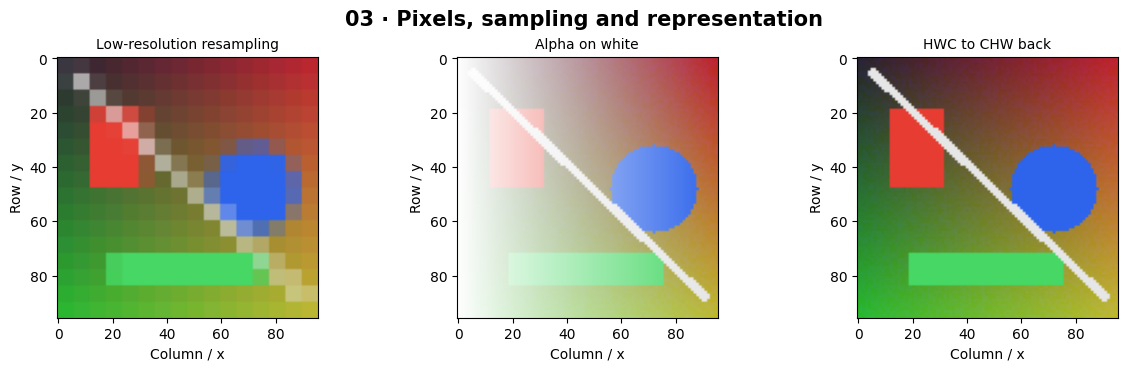

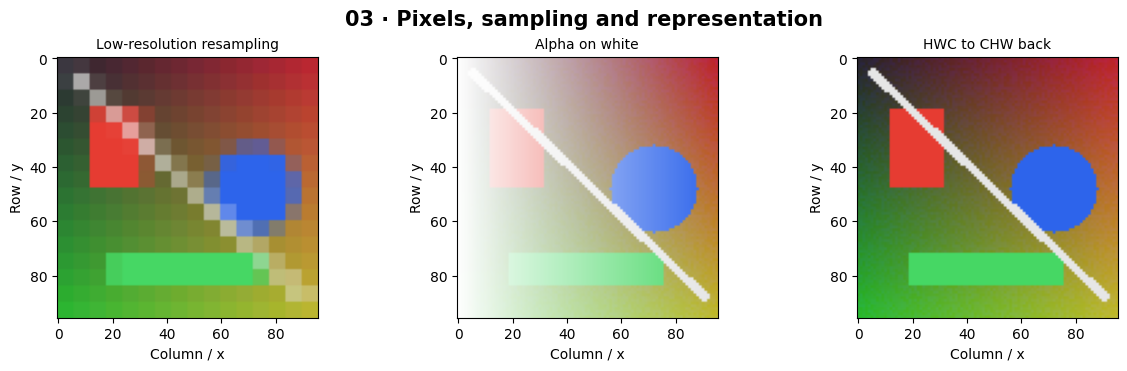

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Image Inspector**. Explain sampling, quantization and image memory. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Pixel coordinates are not Cartesian world coordinates: y normally increases downward. Alpha is not another visible color channel.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Reduce the number of intensity levels while leaving resolution fixed. Then reduce resolution with all 256 levels. Describe how the two artifacts differ.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Write an image inspector that reports format, size, dtype, channel order and memory, and rejects ambiguous two-channel arrays.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Resolution describes the sampling grid. Reducing it loses spatial information; enlarging it cannot recover missing detail. Alpha compositing combines foreground and background using opacity. HWC and CHW contain the same values in different axis orders; reshape alone does not perform this permutation. Metadata such as EXIF orientation can change intended display.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[04 · OpenCV Fundamentals](../../04-opencv-fundamentals/README.md)

[Primary reference](https://pillow.readthedocs.io/en/stable/handbook/concepts.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)